SQL- Python Script

Import Libraries

In [2]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Connect to Duckdb

In [3]:
conn = duckdb.connect("../database/wine_database.duckdb")
cur = conn.cursor()

In [4]:
# Ensure region columns are synonimous

cur.execute("""ALTER TABLE winemag_clean ADD COLUMN region_clean TEXT;
UPDATE winemag_clean
SET region_clean = 
    CASE 
        WHEN region_1 IS NOT NULL AND region_1 <> '' THEN region_1
        ELSE region_2
    END;
""")

In [5]:
cur.execute("""UPDATE winemag_clean
SET region_clean = 
    CASE
        WHEN region_clean = 'Loire Valley' THEN 'Loire'
        WHEN region_clean = 'Bourgogne' THEN 'Burgundy'
        WHEN region_clean = 'Cote de Beaune' THEN 'Côte De Beaune'
        ELSE region_clean
    END;

""")

In [6]:
conn.execute("SHOW TABLES").fetchall()

[('grape_quality_clean',), ('vivino_clean',), ('winemag_clean',)]

In [7]:
conn.execute("SELECT * FROM winemag_clean LIMIT 5").df()

,variety,winery,country,province,region_1,region_2,points,price,region_clean
0,White Blend,Nicosia,Italy,Sicily & Sardinia,Etna,None,87,NaN,Etna
1,Portuguese Red,Quinta Dos Avidagos,Portugal,Douro,None,None,87,15.0,None
2,Pinot Gris,Rainstorm,Us,Oregon,Willamette Valley,Willamette Valley,87,14.0,Willamette Valley
3,Riesling,St. Julian,Us,Michigan,Lake Michigan Shore,None,87,13.0,Lake Michigan Shore
4,Pinot Noir,Sweet Cheeks,Us,Oregon,Willamette Valley,Willamette Valley,87,65.0,Willamette Valley


In [8]:
conn.execute("SELECT * FROM vivino_clean LIMIT 5").df()

,country,rating,wine_name,winery_name,ratings_count,wine_type,region,is_natural
0,Chile,3.9,Reserva Especial Carménère,Terranoble,341,Red,Aconcagua Valley,False
1,Australia,3.3,Regional Series Chardonnay,Lindeman's,666,White,Adelaide Hills,False
2,Argentina,3.6,Alto Agrelo Grande Reserve Malbec,Alta Vista,154,Red,Agrelo,False
3,Argentina,4.0,Lote Agrelo Malbec,Bodega Norton,2088,Red,Agrelo,False
4,Argentina,3.9,Appellation Agrelo Cabernet Sauvignon,Catena,3850,Red,Agrelo,False


In [9]:
conn.execute("SELECT * FROM grape_quality_clean LIMIT 5").df()

,sample_id,variety,region,quality_score,quality_category,sugar_content_brix,acidity_ph,cluster_weight_g,berry_size_mm,harvest_date,sun_exposure_hours,soil_moisture_percent,rainfall_mm
0,1,Riesling,Barossa Valley,2.11,Medium,13.70,3.17,251.81,18.58,2023-09-04,8.4,55.9,223.3
1,2,Pinot Noir,Loire Valley,2.83,High,20.84,3.15,289.00,22.08,2023-09-16,8.8,36.9,312.1
2,3,Sauvignon Blanc,Napa Valley,3.52,Premium,27.46,4.07,125.14,21.40,2023-08-25,11.1,64.9,698.7
3,4,Riesling,Napa Valley,2.28,Medium,24.64,3.15,237.46,12.31,2023-09-13,8.0,54.5,660.1
4,5,Merlot,Napa Valley,2.90,High,26.13,3.18,221.52,12.24,2023-08-11,11.2,36.3,410.4


In [10]:
df = conn.execute("""
-- See what's actually in each table
SELECT DISTINCT region FROM grape_quality_clean ORDER BY region;
SELECT DISTINCT region FROM vivino_clean WHERE country = 'France' ORDER BY region;
                  """).df()
df

,region
0,Alsace
1,Bordeaux
2,Bourgogne
3,Chablis
4,Champagne
5,Côte De Beaune
6,Loire Valley
7,Pessac-Léognan
8,Rhone Valley


In [11]:
conn.execute("""
    SELECT DISTINCT variety
    FROM grape_quality_clean
    WHERE region IN ('Bordeaux', 'Loire Valley')
    ORDER BY variety
""").df()

,variety
0,Cabernet Sauvignon
1,Chardonnay
2,Merlot
3,Pinot Noir
4,Riesling
5,Sauvignon Blanc
6,Syrah
7,Zinfandel


In [12]:
conn.execute("DESCRIBE vivino_clean").df()

,column_name,column_type,null,key,default,extra
0,country,VARCHAR,YES,None,None,None
1,rating,DOUBLE,YES,None,None,None
2,wine_name,VARCHAR,YES,None,None,None
3,winery_name,VARCHAR,YES,None,None,None
4,ratings_count,INTEGER,YES,None,None,None
5,wine_type,VARCHAR,YES,None,None,None
6,region,VARCHAR,YES,None,None,None
7,is_natural,BOOLEAN,YES,None,None,None


In [13]:
conn.execute("DESCRIBE winemag_clean").df()

,column_name,column_type,null,key,default,extra
0,variety,VARCHAR,YES,None,None,None
1,winery,VARCHAR,YES,None,None,None
2,country,VARCHAR,YES,None,None,None
3,province,VARCHAR,YES,None,None,None
4,region_1,VARCHAR,YES,None,None,None
5,region_2,VARCHAR,YES,None,None,None
6,points,BIGINT,YES,None,None,None
7,price,DOUBLE,YES,None,None,None
8,region_clean,VARCHAR,YES,None,None,None


In [14]:
conn.execute("""
    SELECT MIN(price), MAX(price), AVG(price), COUNT(*)
    FROM winemag_clean
    WHERE price IS NOT NULL
""").df()

,min(price),max(price),avg(price),count_star()
0,4.0,3300.0,34.749542,200724


In [15]:
conn.execute("""
    SELECT
        country,
        variety,
        price,
        points,
        winery
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND points IS NOT NULL
      AND country IN ('France', 'Italy', 'US', 'Spain', 'Argentina')
    
""").df()

,country,variety,price,points,winery
0,Spain,Tempranillo-Merlot,15.0,87,Tandem
1,Italy,Frappato,16.0,87,Terre Di Giurfo
2,France,Gewürztraminer,24.0,87,Trimbach
3,France,Pinot Gris,27.0,87,Jean-Baptiste Adam
4,France,Gewürztraminer,30.0,87,Leon Beyer
...,...,...,...,...,...
72468,Spain,Albariño,17.0,89,Nessa
72469,Italy,Carricante,80.0,89,Benanti
72470,Italy,Grillo,15.0,89,Caruso & Minini
72471,Italy,Nerello Mascalese,52.0,89,Cottanera


In [16]:
# See wine cost
conn.execute("""
    SELECT MIN(price), MAX(price), AVG(price), COUNT(*)
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND price <= 200
""").df()

,min(price),max(price),avg(price),count_star()
0,4.0,200.0,32.78307,199539


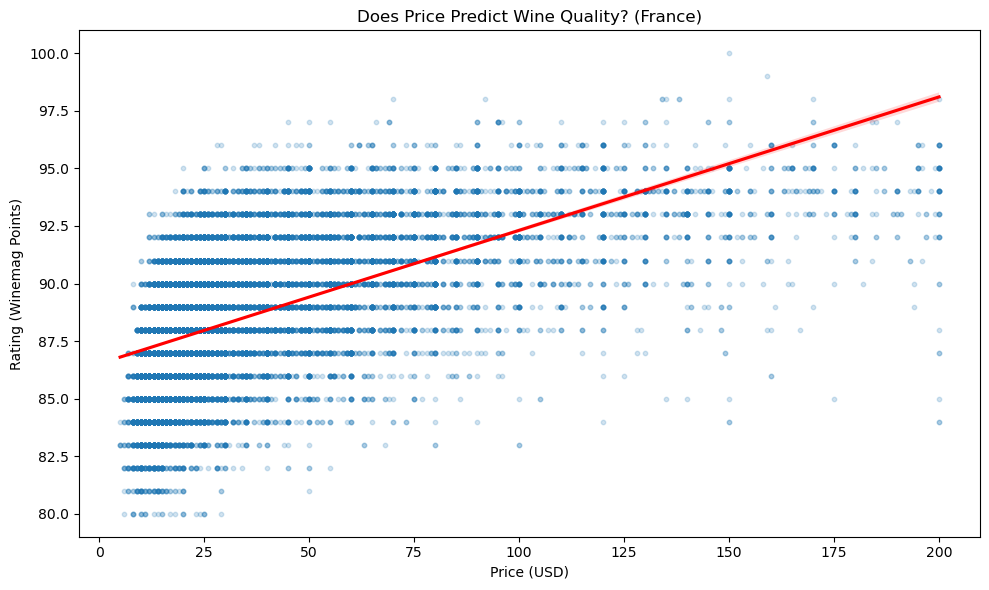

In [17]:
df_france = conn.execute("""
    SELECT variety, price, points
    FROM winemag_clean
    WHERE price IS NOT NULL
      AND points IS NOT NULL
      AND price <= 200
      AND country = 'France'
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=df_france,
    x='price',
    y='points',
    scatter_kws={'alpha': 0.2, 's': 10},
    line_kws={'color': 'red'},
    ax=ax
)

ax.set_title('Does Price Predict Wine Quality? (France)')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

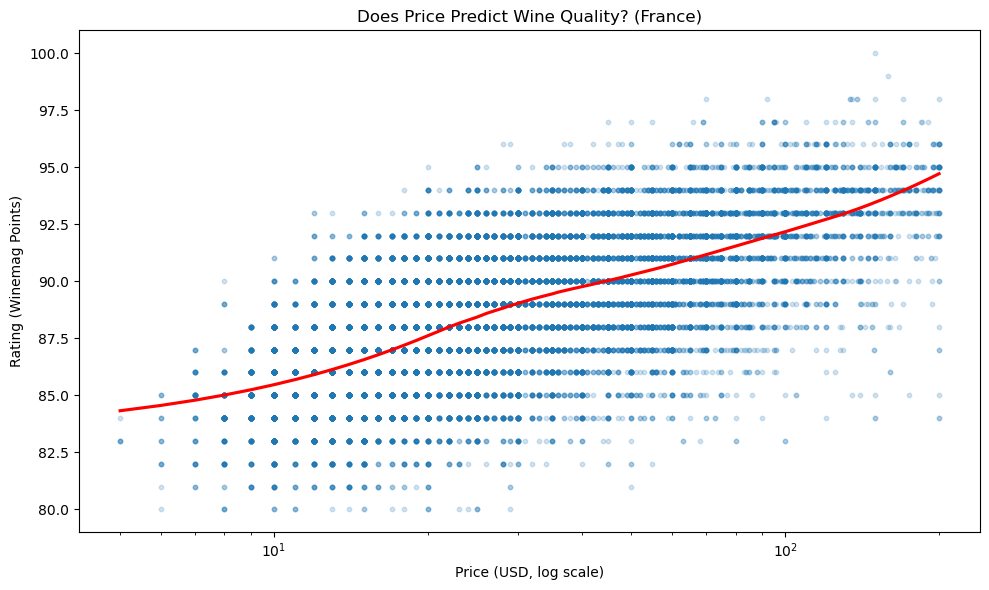

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=df_france,
    x='price',
    y='points',
    scatter_kws={'alpha': 0.2, 's': 10},
    line_kws={'color': 'red'},
    lowess=True,
    ax=ax
)

ax.set_xscale('log')
ax.set_title('Does Price Predict Wine Quality? (France)')
ax.set_xlabel('Price (USD, log scale)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Custom theme
plt.style.use("default")
sns.set_theme(context="notebook", style="whitegrid")

custom_colors = {
    "background": "#FDFAF7",   # off-white
    "text": "#2C2C2C",         # near-black
    "accent": "#C49A3C",       # warm gold
    "highlight": "#5C1A2E",    # deep burgundy
}

plt.rcParams.update({
    "figure.facecolor": custom_colors["background"],
    "axes.facecolor": custom_colors["background"],
    "axes.edgecolor": custom_colors["highlight"],
    "axes.labelcolor": custom_colors["text"],
    "xtick.color": custom_colors["text"],
    "ytick.color": custom_colors["text"],
    "text.color": custom_colors["text"],
    "axes.titleweight": "bold",
    "axes.titlecolor": custom_colors["highlight"],
    "axes.titlesize": 16,
})


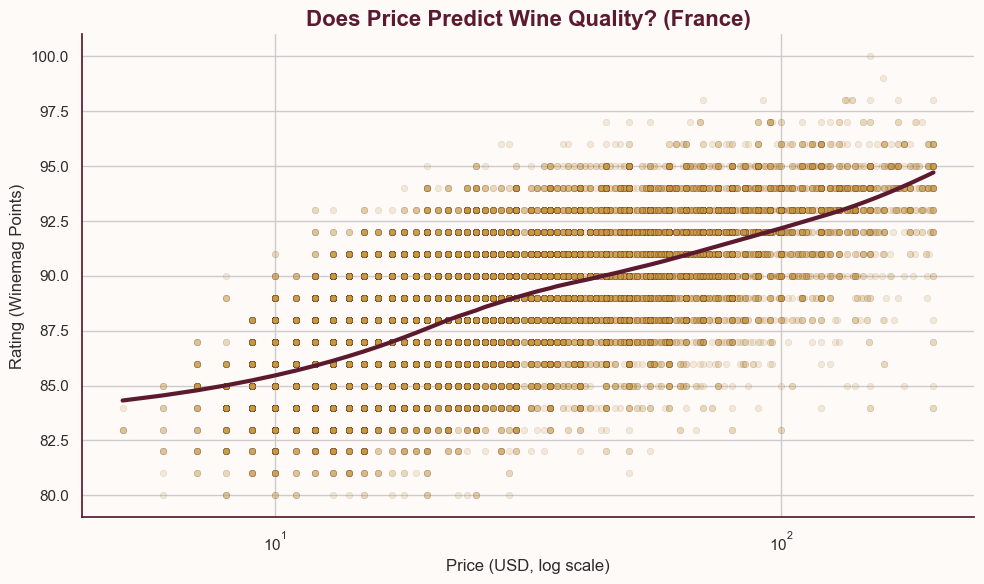

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df_france,
    x='price',
    y='points',
    scatter_kws={
        'alpha': 0.18,
        's': 22,
        'color': '#C49A3C',          # warm gold
        'edgecolor': '#5C1A2E',      # deep burgundy outline
        'linewidths': 0.3            # <-- FIXED (use linewidths)
    },
    line_kws={
        'color': '#5C1A2E',          # deep burgundy trend line
        'linewidth': 3
    },
    lowess=True,
    ax=ax
)

ax.set_xscale('log')
ax.set_title('Does Price Predict Wine Quality? (France)', color='#5C1A2E', weight='bold')
ax.set_xlabel('Price (USD, log scale)', color='#2C2C2C')
ax.set_ylabel('Rating (Winemag Points)', color='#2C2C2C')

sns.despine()
plt.tight_layout()
plt.show()


In [49]:
df_value = conn.execute("""
    SELECT variety, price, points, winery
    FROM winemag_clean
    WHERE country = 'France'
      AND points >= 90
      AND price <= 20
      AND price IS NOT NULL
      AND variety IS NOT NULL
    ORDER BY points DESC, price ASC
""").df()

print(df_value['variety'].nunique())
df_value.head()

60


,variety,price,points,winery
0,Red Blend,20.0,95,Alain Brumont
1,Petit Manseng,18.0,94,Domaine Cauhapé
2,Malbec,20.0,94,Château Du Cèdre
3,Red Blend,20.0,94,Alain Brumont
4,Rosé,20.0,94,Château Vignelaure


In [29]:
top_varieties = df_value['variety'].value_counts().head(10).index
df_plot = df_value[df_value['variety'].isin(top_varieties)].copy()

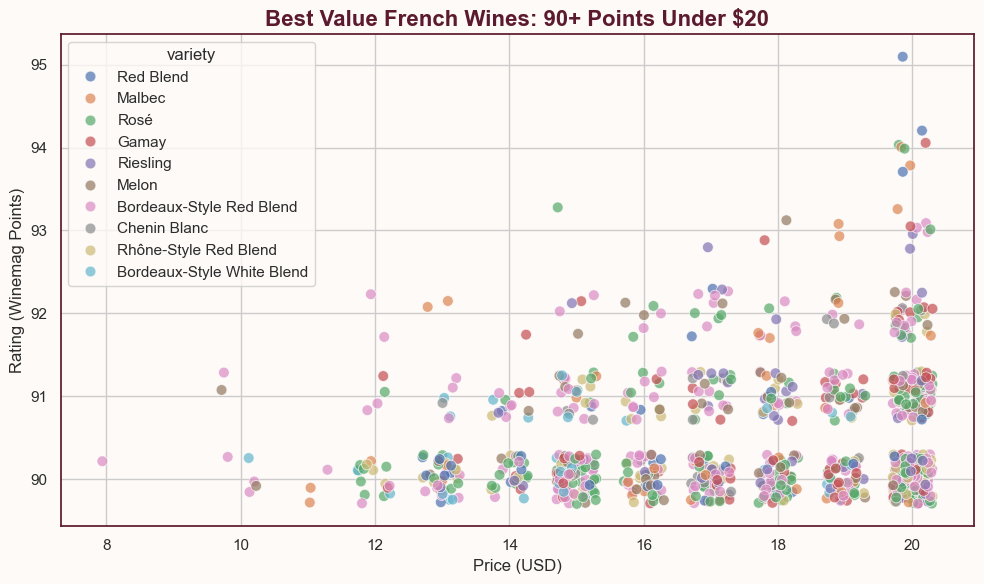

In [30]:
df_plot['points_jittered'] = df_plot['points'] + np.random.uniform(-0.3, 0.3, len(df_plot))
df_plot['price_jittered'] = df_plot['price'] + np.random.uniform(-0.3, 0.3, len(df_plot))

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='price_jittered',
    y='points_jittered',
    hue='variety',
    alpha=0.7,
    s=60,
    ax=ax
)

ax.set_title('Best Value French Wines: 90+ Points Under $20')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Rating (Winemag Points)')
plt.tight_layout()
plt.show()

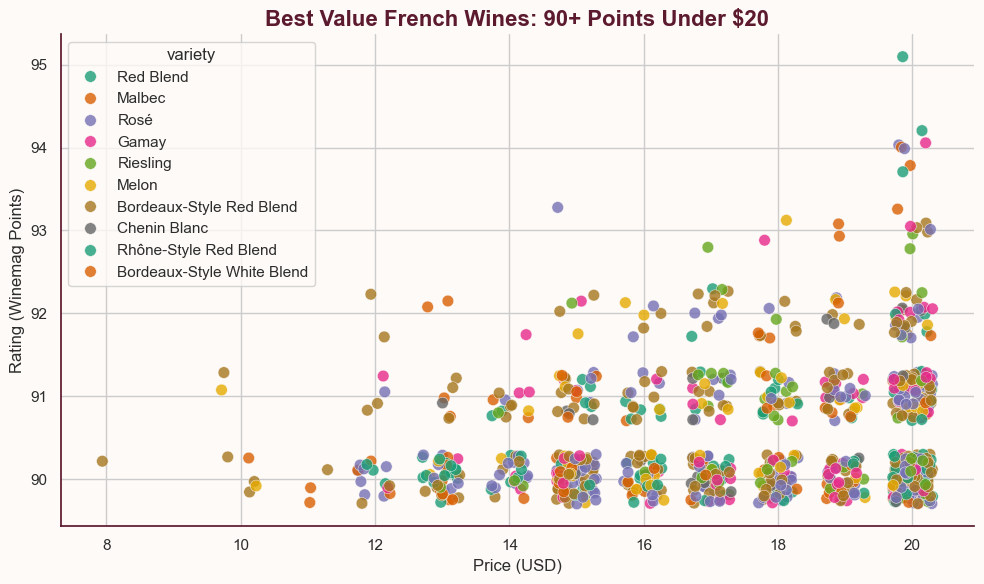

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df_plot,
    x='price_jittered',
    y='points_jittered',
    hue='variety',
    palette='Dark2',   # richer, more elegant palette
    alpha=0.8,
    s=70,
    edgecolor=custom_colors["background"],
    linewidth=0.4,
    ax=ax
)

ax.set_title('Best Value French Wines: 90+ Points Under $20')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Rating (Winemag Points)')

sns.despine()
plt.tight_layout()
plt.show()


In [50]:
df_funfact = conn.execute("""
    SELECT 
        variety,
        COUNT(DISTINCT variety || '|' || winery) AS n_wines
    FROM winemag_clean
    WHERE country = 'France'
      AND points >= 90
      AND price <= 20
      AND price IS NOT NULL
      AND variety IS NOT NULL
      AND winery IS NOT NULL
    GROUP BY variety
    ORDER BY n_wines DESC
    LIMIT 10;
""").df()


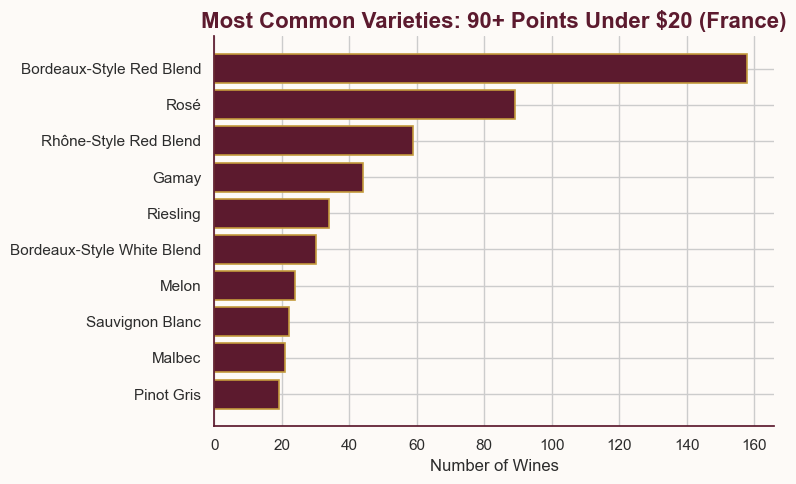

In [51]:
# Custom palette to match your slide theme
burgundy = "#5C1A2E"
gold = "#C49A3C"
offwhite = "#FDFAF7"
nearblack = "#2C2C2C"

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(offwhite)
ax.set_facecolor(offwhite)

ax.barh(
    df_funfact['variety'],
    df_funfact['n_wines'],
    color=burgundy,
    edgecolor=gold,
    linewidth=1.2
)

ax.set_xlabel('Number of Wines', color=nearblack)
ax.set_title('Most Common Varieties: 90+ Points Under $20 (France)',
             color=burgundy, weight='bold')

ax.tick_params(colors=nearblack)
ax.invert_yaxis()
sns.despine()

plt.tight_layout()
plt.show()


In [23]:
# Close the connection
conn.close()